<a href="https://colab.research.google.com/github/harishmuh/Deep-Learning_study/blob/main/01_mnist_classification_using_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Multi layer perceptron - MNIST digit with Pytorch**
---

![image](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

## **Context**

In this tutorial, we will build a neural network model to classify handwritten digits using Pytorch. This model is called as Multi layer perceptron.

**Multi Layer Perceptron (MLP)**

MLP is a type of neural network with an architecture consisting of input, hidden, and output layers of interconnected neurons. This network is capable of learning complex patterns and performing tasks such as classification and regression by adjusting its parameters through training.



**About Handwritten digits - MNIST dataset**

![eight](https://user-images.githubusercontent.com/51207580/59979373-bc052480-9604-11e9-85b8-464367fdc891.png)

Dataset Characteristics:

* 70,000 grayscale images

    * 60,000 training images

    * 10,000 test images

* Image size: 28 × 28 pixels (784 total pixels)

* Pixel range: 0–255

* 10 labels/classes (digits 0–9)

We will build the MLP architecture as below:

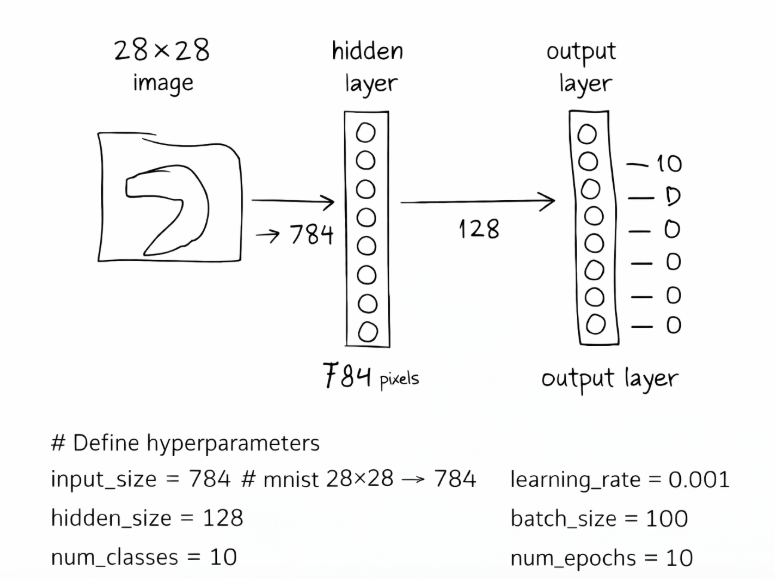

## **Initial setup**

In this step, we will importing required libraries, loading dataset, and setting data loaders.

**Importing libraries**

In [1]:
# Importing libraries
import torch
import torch.nn as nn                       # Build neural network/construct layer
import torch.optim as optim                 # Define optimizer
import torchvision.datasets as datasets     # Loading dataset
import torchvision.transforms as transforms # preprocesssing data
from torch.utils.data import DataLoader     # A module used for data preprocessing before inputting it into the model
# DataLoader has several features
# 1. Multiprocessing data processing
# 2. Automatic batching, Previously 1 batch is 1 sample, after batching: 1 batch into 8 samples or 16 samples
# 3. Shuffling, which shuffles every full iteration of the call, e.g.: 0-10 (567812034), (079324561)
# 4. collate_fn, each data call can be passed a collate function to process data

# Set random seeds for reproducibility
torch.manual_seed(42)


# Checking PyTorch version
print('PyTorch version:', torch.__version__)

# Defining device (We set device manually in Pytorch)
# Checking if CUDA NVIDIA is available in the system or we use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Using device:', device)

PyTorch version: 2.10.0+cpu
Using device: cpu


In [2]:
# Define hyperparameters for the experiment
input_size = 784  # mnist digit dimension: 28x28 pixels (2D matrix) -> converted ('flatten') into 784 (1D matrix)
hidden_size = 128 # Hidden layer
num_classes = 10
learning_rate = 0.001
batch_size = 100
num_epochs = 10 # number of iteration training

**Working with data**

PyTorch has two primitive ways to work as `torch.utils.data.DataLoader` and `torch.utils.data.Dataset`. `Dataset`
stores the samples and their corresponding labels, while `DataLoader`
wraps an iterable around the `Dataset`.

**Loading dataset**

In [3]:
# Downloading MNIST dataset and transform them to tensor
# Previously the data are on numpy-array for format, we need to transform it to tensor
train_dataset = datasets.MNIST(
    root="data", train=True, transform=transforms.ToTensor(), download=True
) # format:torch.utils.data.Dataset
test_dataset = datasets.MNIST(
    root="data", train=False, transform=transforms.ToTensor()
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 58.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.65MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.8MB/s]


In [4]:
# Checking data
# Train data
print('Training rows:', len(train_dataset))
# Test data
print('Test rows:', len(test_dataset))

Training rows: 60000
Test rows: 10000


**Setting data loaders**

In [5]:
# Create data loaders
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [6]:
for images, labels in train_loader:
    print(f"Shape of X [N, C, H, W]: {images.shape}")
    print(f"Shape of y: {labels.shape}, data type: {labels.dtype}")
    break # We only need to check the first batch

Shape of X [N, C, H, W]: torch.Size([100, 1, 28, 28])
Shape of y: torch.Size([100]), data type: torch.int64


**Displaying sample image**

=== Batch Information ===
Shape of X [N, C, H, W]: torch.Size([100, 1, 28, 28])
Shape of y: torch.Size([100])
Label data type: torch.int64
First 10 labels: [9, 9, 4, 7, 7, 9, 4, 7, 9, 1]


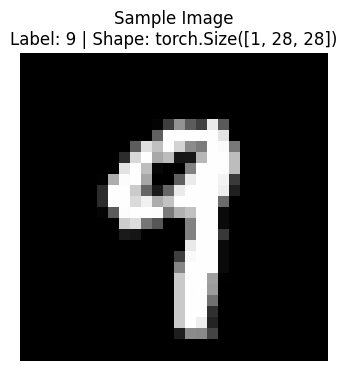

In [7]:
# Displaying sample image and batch information from data loader
import matplotlib.pyplot as plt

# Getting first batch from DataLoader
images, labels = next(iter(train_loader))

# Displaying batch information
print("=== Batch Information ===")
print(f"Shape of X [N, C, H, W]: {images.shape}")
print(f"Shape of y: {labels.shape}")
print(f"Label data type: {labels.dtype}")

# Displaying first 10 labels
print(f"First 10 labels: {labels[:10].tolist()}")

# Showing sample image
plt.figure(figsize=(4, 4))
plt.imshow(images[0].squeeze(), cmap='gray')

# Add image information to title
plt.title(
    f"Sample Image\n"
    f"Label: {labels[0].item()} | "
    f"Shape: {images[0].shape}"
)
plt.axis('off')
plt.show()

## **Model building**

In this step, we will construct MLP model architecture for the experiment.

**Creating models**

To define a neural network in PyTorch, we create a class that inherits from nn.Module. We define the layers of the network in the `__init__` function and specify how data will pass through the network in the `forward` function. To accelerate operations in the neural network, we move it to the accelerator such as CUDA. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

In [8]:
# Define MLP model
# Every time we define a neural network module using PyTorch, we must inherit or make nn.Module the parent class.
# So that all functions in the nn.Module class can be used by its derived classes.

# Defining model by creating class
class MLP(nn.Module):

# Defining layers of the network
    # We make constructor with parameters such as,
    # input_size: The input size of the network
    # hidden_size: The number of nodes in the hidden layer
    # output_size: The number of nodes in the output layer
    # output_size is the number of classes in onehot encoding format, e.g, 0 -> [1 0 0 0 0 0 0 0 0]
    def __init__(self, input_size, hidden_size, num_classes):
        # We must call the constructor of the super class (the parent class)
        super(MLP, self).__init__()
        # define self.fc1 (fully connected 1) nn.Linear(input_size, output_size), output_size represents the output size of the node.
        self.fc1 = nn.Linear(input_size, hidden_size)
        # activation function -> ReLU: max(0, value)
        self.relu = nn.ReLU()

        # define the second layer of the network with an input of hidden size, and an output of num_class
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.reshape(x.shape[0], -1) # flattening done Manually
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Initializing MLP model
model = MLP(input_size, hidden_size, num_classes).to(device)
print(model)

MLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


* node 1 = i_1 * w11 + i_2 * w12 + b

* node 2 = i_1 * w21 + i_2 * w22 + b

* node 3 = i_1 * w31 + i_2 * w32 + b

i: input_, w : weight_, b: bias

**Initializing loss function and optimizer**

Before training a model, we need a `loss function` and `an optimizer`.
* **Loss function/criterion** is a module used to penalize our model and check whether the prediction results are correct
* **Optimizer** is a module used to update the parameters (usually weights) in the model. The value of weights will be upgraded during learning process

In [9]:
# Initializing loss function and optimizer

# Defining loss function/criterion
criterion = nn.CrossEntropyLoss()

# Defining optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

## **Model training**

In this step, we will set model training parameters. In a single training loop, the model makes predictions on the training dataset (fed to it in batches), and backpropagates the prediction error to adjust the model's parameters.

In [10]:
# Function for model training
# Optimizing loop
def train(model, data_loader, criterion, optimizer, device):

    # We change our model mode into training
    model.train()

    # Variable to store several metrics that will be displayed later during the training process
    total_loss = 0
    correct = 0
    total = 0

    # Iterate data over the data loader, we get images and labels
    for batch_idx, (images, labels) in enumerate(data_loader):
        images = images.to(device) # We change our image device to the desired device function
        labels = labels.to(device) # We change the labels as well based on the device function

        optimizer.zero_grad()# We delete all gradients stored by the optimizer
        outputs = model(images) # Feedforward process, we predict the input data to the model
        loss = criterion(outputs, labels) # The process of comparing the predicted output with the ground truth or labels
        loss.backward()  # The backpropagation process
        optimizer.step() # The process of changing the parameters based on the Backpropagation result

        total_loss += loss.item() # we store the loss value


        #an operation to calculate accuracy
        _, predicted = outputs.max(1) # network output: (B (batch), num_class (output size))
        total += labels.size(0) # we store the total value
        correct += predicted.eq(labels).sum().item() # storing the number of correct values ​​into the variable correct
        # eq: equals, .item() -> to get only the values (not in torch.tensor format)

    return total_loss / len(data_loader), 100.0 * correct / total

## **Model evaluation**

In this step we will define measured metrics for model evaluation. We will also check the model's performance against the test dataset to ensure it is learning.

In [11]:
# Model evaluation

from sklearn.metrics import precision_score, recall_score, f1_score

# Defining model evaluation
# Similar to previous model training
# but without optimizer (because we don't update weight and bias in this step)
def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    predicted_labels = []
    true_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            predicted_labels.extend(predicted.tolist())
            true_labels.extend(labels.tolist())

    precision = precision_score(true_labels, predicted_labels, average="macro")# precision metrics
    recall = recall_score(true_labels, predicted_labels, average="macro")# sensitivity metrics
    f1 = f1_score(true_labels, predicted_labels, average="macro")# f1 metrics to balance between precision dan recall
    # precision: TP/(TP+FP)
    # recall: TP/(TP+FN)
    # f1 score: 2*(Precision*Recall)/Precision+Recall
    return (
        total_loss / len(data_loader),
        100.0 * correct / total,
        precision,
        recall,
        f1,
        predicted_labels,
        true_labels,
    )

The training process is conducted over several iterations (epochs). Previously we have set the number of epochs as 10. During each epoch, the model learns parameters to make better predictions. We print the model's accuracy and loss at each epoch; we'd like to see the accuracy increase and the loss decrease with every epoch.

In [12]:
# Training loop
for epoch in range(num_epochs):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc, precision, recall, f1, predicted_labels, true_labels = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%"
        f" | "
        f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%, "
        f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}"
    )

print('Done !')

Epoch [1/10], Train Loss: 0.3882, Train Acc: 89.73% | Test Loss: 0.2113, Test Acc: 93.90%, Precision: 0.9384, Recall: 0.9383, F1: 0.9381
Epoch [2/10], Train Loss: 0.1788, Train Acc: 94.91% | Test Loss: 0.1439, Test Acc: 95.82%, Precision: 0.9582, Recall: 0.9577, F1: 0.9578
Epoch [3/10], Train Loss: 0.1258, Train Acc: 96.44% | Test Loss: 0.1125, Test Acc: 96.61%, Precision: 0.9662, Recall: 0.9657, F1: 0.9658
Epoch [4/10], Train Loss: 0.0957, Train Acc: 97.26% | Test Loss: 0.0969, Test Acc: 96.97%, Precision: 0.9696, Recall: 0.9695, F1: 0.9695
Epoch [5/10], Train Loss: 0.0763, Train Acc: 97.79% | Test Loss: 0.0868, Test Acc: 97.26%, Precision: 0.9726, Recall: 0.9724, F1: 0.9724
Epoch [6/10], Train Loss: 0.0635, Train Acc: 98.11% | Test Loss: 0.0860, Test Acc: 97.37%, Precision: 0.9738, Recall: 0.9736, F1: 0.9736
Epoch [7/10], Train Loss: 0.0525, Train Acc: 98.42% | Test Loss: 0.0758, Test Acc: 97.69%, Precision: 0.9769, Recall: 0.9768, F1: 0.9768
Epoch [8/10], Train Loss: 0.0444, Train A

**Confusion matrix**

A confusion matrix is a performance measurement tool for machine learning classification models, summarizing how well a model predicts by comparing actual target values with predicted values.

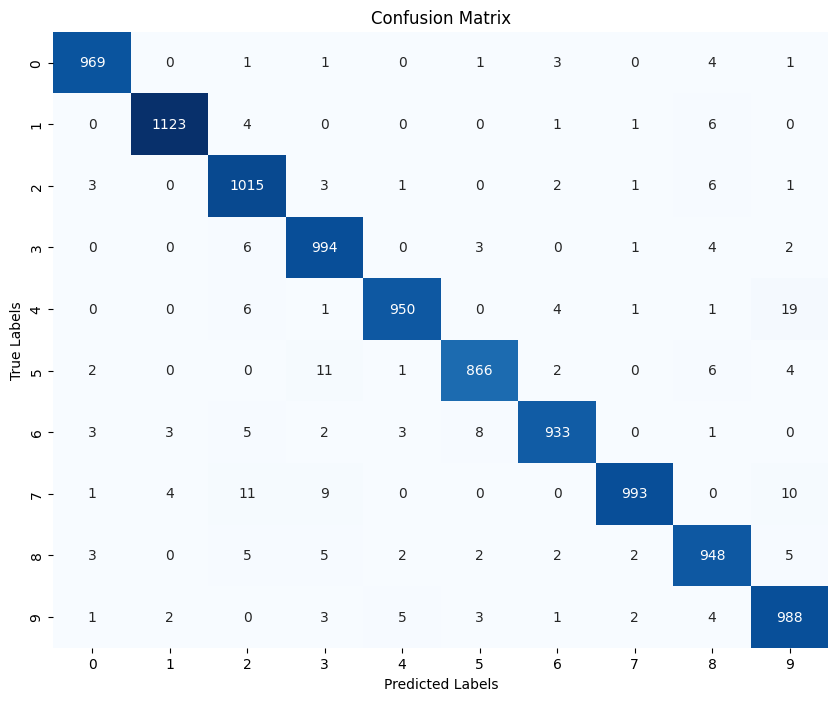

In [13]:
# Confusion matrix

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create a confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

## **Simulate prediction**

In this step, we will try to simulate the prediction process using our model.

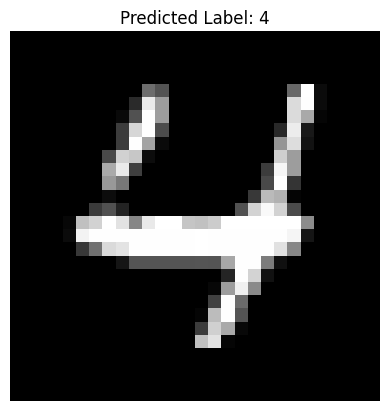

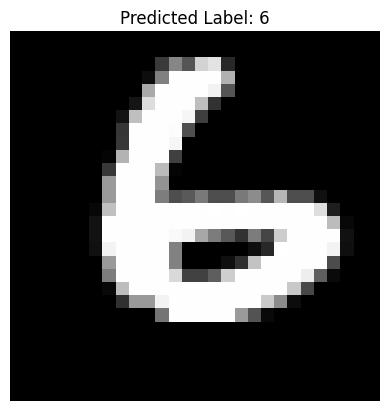

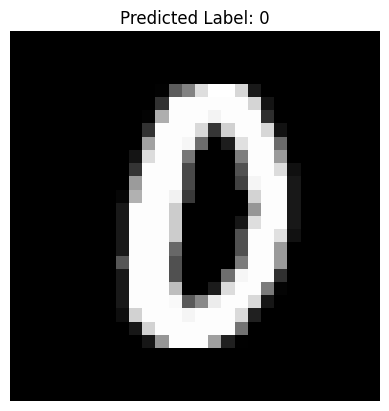

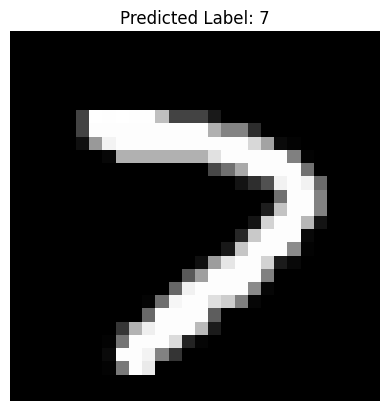

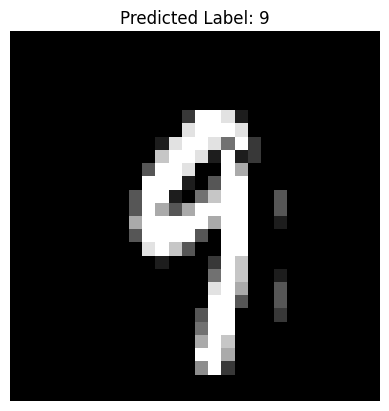

In [14]:
# Prediction simulation

import numpy as np
import matplotlib.pyplot as plt

# Function to display the image and predicted label
def show_prediction(image, predicted_label):
    #plt.imshow: display image
    plt.imshow(image.squeeze(), cmap="gray") # C,H,W -> h,w (requires 2D)
    # we turn off the axis so that the displayed image is smoother
    plt.axis("off")
    # We give the predicted label to title
    plt.title(f"Predicted Label: {predicted_label}")
    plt.show()

# Specify the number of sample images to test
num_samples = 5

# Select random sample images from the test set
sample_indices = np.random.choice(len(test_dataset), num_samples, replace=False)

for index in sample_indices:
    sample_image, sample_label = test_dataset[index]
    sample_image = sample_image.to(device).unsqueeze(0) #because the input model wants our image to be in a format: (Batch, h, w)

    # Make the prediction
    model.eval()# change the mode model to eval
    with torch.no_grad():# this is an operation to lighten our gpu
        output = model(sample_image)# output prediction from model with input sample_img
        _, predicted = torch.max(output.data, 1) # we get the maximum index from torch.max of the prediction result

    # Convert the tensor to a numpy array
    sample_image = sample_image.cpu().squeeze().numpy() # Converting format again B,C,H,W -> C,H,W

    # Display the sample image and predicted label
    show_prediction(sample_image, predicted.item())

In overall, we can see that the model can make correct prediction for the simulation process.

**Displaying Wrong Predictions**

Now, let's also visualize some of the images that the model misclassified. This can help in understanding where the model might be struggling.

Displaying 5 wrongly predicted images:


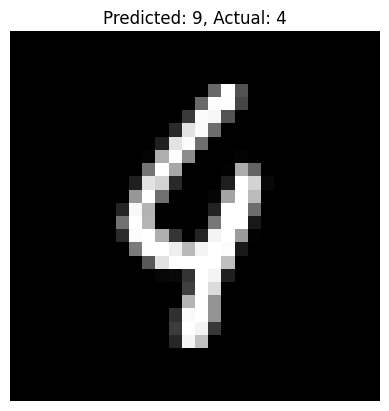

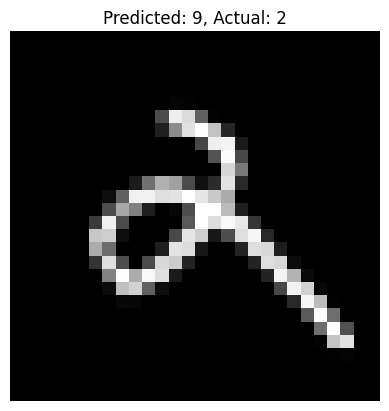

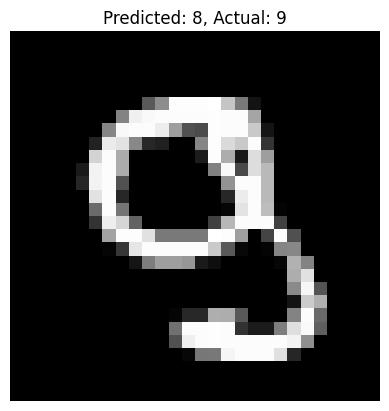

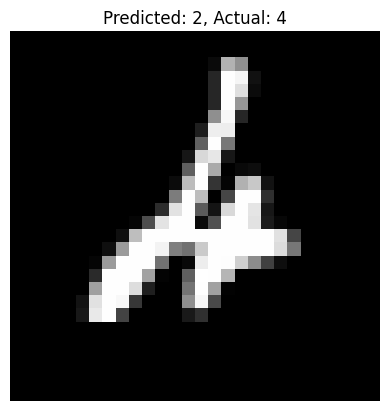

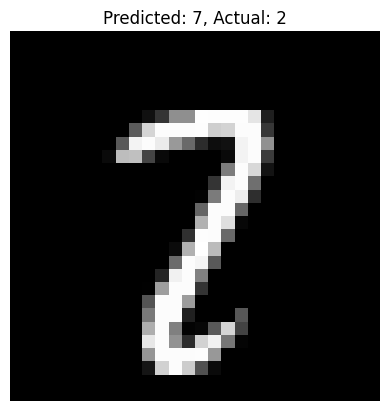

In [15]:
# Find indices of wrongly predicted images

classes = [str(i) for i in range(10)]

wrong_predictions_indices = [
    i for i, (pred, actual) in enumerate(zip(predicted_labels, true_labels)) if pred != actual
]

# Display a few wrong predictions (e.g., first 5 or fewer if not enough)
num_wrong_to_show = min(5, len(wrong_predictions_indices))

print(f"Displaying {num_wrong_to_show} wrongly predicted images:")
for i in range(num_wrong_to_show):
    index = wrong_predictions_indices[i]
    sample_image, actual_label_idx = test_dataset[index]

    # Prepare image for model prediction
    sample_image_tensor = sample_image.to(device).unsqueeze(0)

    # Make the prediction
    model.eval()
    with torch.no_grad():
        output = model(sample_image_tensor)
        _, predicted_label_idx = torch.max(output.data, 1)

    # Convert tensor to numpy for display
    display_image = sample_image.cpu().squeeze().numpy()
    predicted_label = classes[predicted_label_idx.item()]
    actual_label = classes[actual_label_idx]

    # Display the image with predicted and actual labels
    plt.figure()
    plt.imshow(display_image, cmap="gray")
    plt.axis("off")
    plt.title(f"Predicted: {predicted_label}, Actual: {actual_label}")
    plt.show()


## **Saving models**
We can save the model for the future use.
A common way to save a model is to serialize the internal state dictionary (containing the model parameters).

In [16]:
# Saving pytorch model
torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")

Saved PyTorch Model State to model.pth


**Loading models**

In [17]:
# Loading the saved models
model = MLP(input_size, hidden_size, num_classes).to(device)
model.load_state_dict(torch.load("model.pth"))

<All keys matched successfully>

In [18]:
# Lets simulate prediction using the saved model

classes = [str(i) for i in range(10)]

model.eval()
x, y = test_dataset[0][0], test_dataset[0][1] # Using test_dataset instead of test_data for consistency
with torch.no_grad():
    x = x.to(device)
    pred = model(x)
    predicted, actual = classes[pred[0].argmax(0)], classes[y]
    print(f'Predicted: "{predicted}", Actual: "{actual}"')


Predicted: "7", Actual: "7"


## **Conclusion**

In this tutorial, we successfully built and trained a Multi-Layer Perceptron (MLP) model using PyTorch to classify handwritten digits from the MNIST dataset. We covered the entire machine learning pipeline, including:

*   **Initial Setup**: Importing necessary libraries, defining hyperparameters, and loading the MNIST dataset with `DataLoader`.
*   **Model Building**: Constructing the MLP architecture with input, hidden, and output layers, and defining the loss function (`CrossEntropyLoss`) and optimizer (`Adam`).
*   **Model Training**: Implementing a training loop to iteratively update model parameters and track performance metrics like loss and accuracy.
*   **Model Evaluation**: Assessing the model's performance on the test set using metrics such as accuracy, precision, recall, and F1-score, and visualizing the results with a confusion matrix.
*   **Prediction Simulation**: Demonstrating the trained model's ability to classify unseen handwritten digits, and also identifying and visualizing misclassified examples to understand model shortcomings.

The model achieved a high accuracy on the test set, indicating its effectiveness in recognizing handwritten digits.

## **Resources**

- PyTorch Documentation: [https://pytorch.org/docs/stable/index.html](https://pytorch.org/docs/stable/index.html)
- MNIST Dataset: [http://yann.lecun.com/exdb/mnist/](http://yann.lecun.com/exdb/mnist/)
- Scikit-learn Metrics: [https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics)